In [1]:
import numpy as np
from matplotlib import pyplot as plt
# import caiman as cm

In [2]:
filepath = '/Users/josieallred/Research/experiment_analysis/data/downloaded_data/K99/miniscope_data/ketamine/R230706A/2023_08_31/15_17_10/saved_movies/please_work.hdf5'
cnmf_obj = cm.source_extraction.cnmf.cnmf.load_CNMF(filepath)
est = cnmf_obj.estimates
C = est.C
np.save('C.npy', C)

Datafile /Users/josieallred/Research/experiment_analysis/data/downloaded_data/K99/miniscope_data/ketamine/R230706A/2023_08_31/15_17_10/saved_movies/please_work.hdf5 not marked as cnmf


In [8]:
print(f'\n we are joining the movies now!! \n')


 we are joining the movies now!! 



In [3]:
fps=30
C = np.load('C.npy')
print(C.shape)
print(C.shape[1]/(fps*60))   # number of minutes

(466, 282771)
157.095


In [4]:
C_curated = np.load('/Users/josieallred/Research/experiment_analysis/data/downloaded_data/K99/miniscope_data/ketamine/R230706A/2023_08_31/15_17_10/saved_movies/C_curated.npz')['C']
print(C.shape)
# plot time series data - a row for each neuron and its firing times
C_diff = C[:, 1:] - C[:, :-1]   # take difference along rows
C_fires = C_diff > 20

event_times = [np.where(row == 1)[0] for row in C_fires]

(466, 282771)


In [4]:
C = np.load('C_combined_avi_v3.npy')
fps = 30

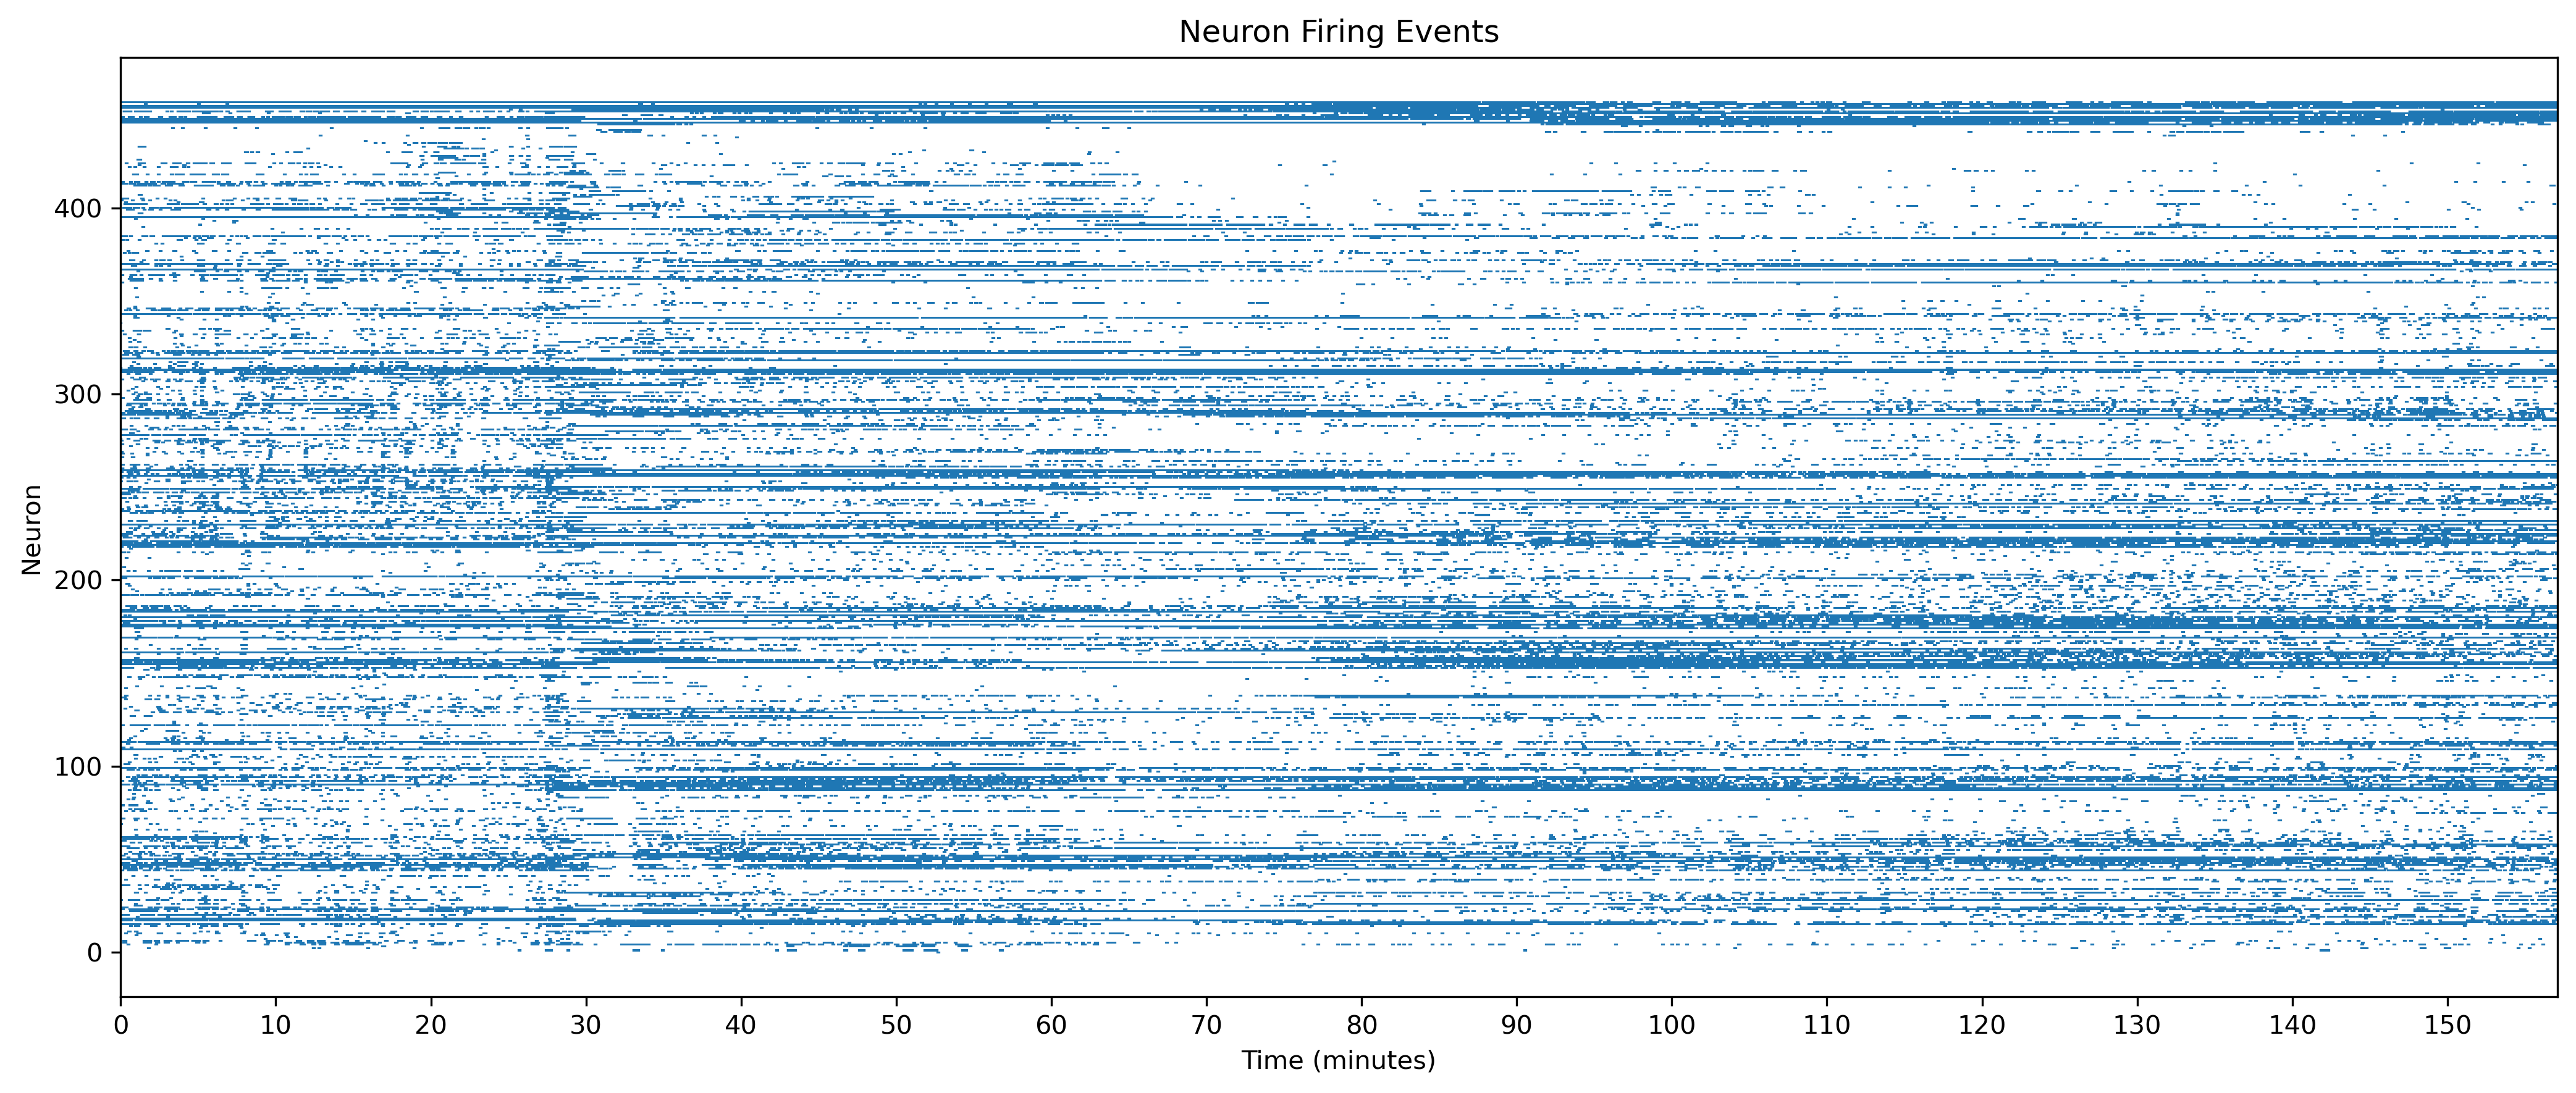

In [5]:
C_diff = C[:, 1:] - C[:, :-1]
C_fires = C_diff > 20

# Convert firing frame indices to minutes
# Add 1 because C_diff[:, 0] corresponds to the change from frame 0 -> frame 1
event_times = [
    (np.where(row)[0] + 1) / (fps * 60)
    for row in C_fires
]

# C_fires has one fewer time point than C
total_minutes = C_fires.shape[1] / (fps * 60)

plt.figure(figsize=(14, 6), dpi=300)
plt.eventplot(event_times)

# Set ticks every 10 minutes
n = 10
minute_ticks = np.arange(0, total_minutes + n, n)
plt.xticks(minute_ticks)

plt.xlabel("Time (minutes)")
plt.ylabel("Neuron")
plt.title("Neuron Firing Events")
plt.xlim(0, total_minutes)
plt.tight_layout()
# plt.savefig('/Users/josieallred/Research/experiment_analysis/data_analysis/big_event2_plot.png', dpi=150)

In [6]:
C_diff = C[:, 1:] - C[:, :-1]
C_fires = C_diff > 20   # an event is if there is a change of at least 20 fluorescence in a single frame
C_sum = np.sum(C_fires, axis=0)

# Find columns where more than 30 entries fired
blips = np.where(C_sum > 30)[0]   # if there were 30 neurons that had an event at one frame call it a blip

if len(blips) > 0:

    groups = np.split(
        blips,
        np.where(np.diff(blips) > 1)[0] + 1
    )
    
    # Event start in C_diff coordinates
    event_starts = np.array([group[0] for group in groups])

    # Convert to original frame coordinates
    event_frames = event_starts + 1

    # C_sum value at each event start
    spike_values = C_sum[event_starts]

    # Differences between consecutive events
    frame_intervals = np.diff(event_frames)
    time_intervals_seconds = frame_intervals / fps

    def format_time(seconds):
        minutes = int(seconds // 60)
        remaining_seconds = seconds % 60
        return f"{minutes:02d}:{remaining_seconds:05.2f}"

    print(f"\nDetected {len(event_frames)} events (C_sum > 30)\n")
    print("=" * 75)
    print(
        f"{'Event':<8}"
        f"{'Frame':<12}"
        f"{'Time':<15}"
        f"{'Frames since prev.':<20}"
        f"{'Time since prev.':<20}"
    )
    print("-" * 75)

    for i, (frame, spike) in enumerate(zip(event_frames, spike_values)):

        event_time_seconds = frame / fps
        event_time = format_time(event_time_seconds)

        if i == 0:
            frames_since = "—"
            time_since = "—"
        else:
            frames_since = str(frame_intervals[i - 1])
            time_since = format_time(time_intervals_seconds[i - 1])

        print(
            f"{i + 1:<8}"
            f"{frame:<12}"
            f"{event_time:<15}"
            f"{frames_since:<20}"
            f"{time_since:<20}"
        )

    print("=" * 75)

else:
    print("No events found where C_sum > 30.")



Detected 4 events (C_sum > 30)

Event   Frame       Time           Frames since prev.  Time since prev.    
---------------------------------------------------------------------------
1       76769       42:38.97       —                   —                   
2       83254       46:15.13       6485                03:36.17            
3       85009       47:13.63       1755                00:58.50            
4       97060       53:55.33       12051               06:41.70            


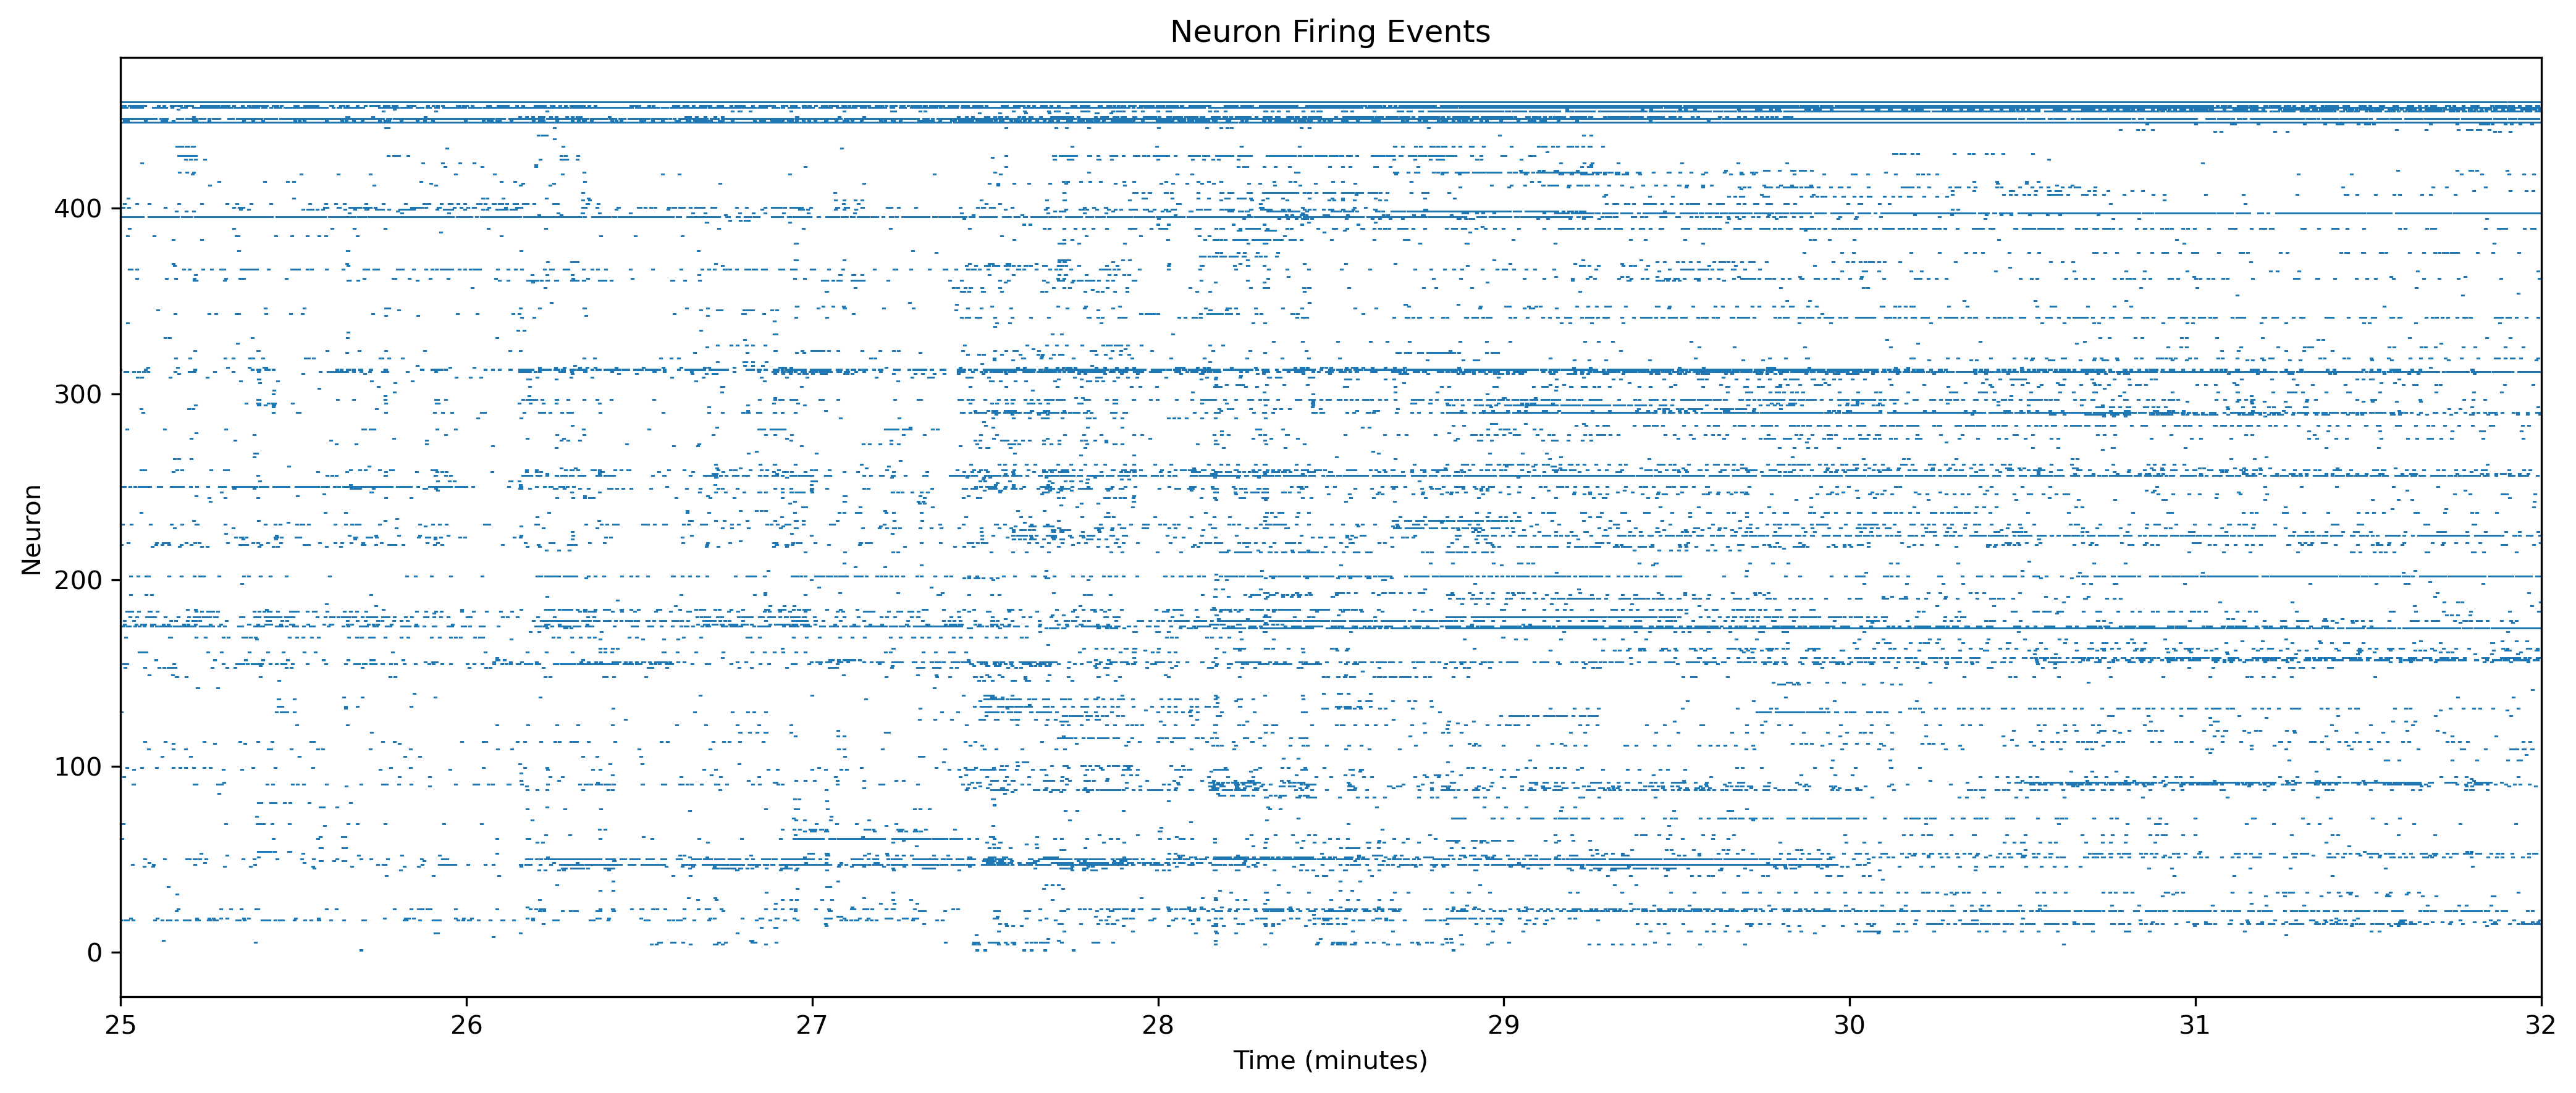

In [7]:
# zoom in on a blip
n1, n2 = 25, 32
fps = 30

C_diff = C[:, 1:] - C[:, :-1]
start_frame = n1 * 60 * fps
end_frame = n2 * 60 * fps
C_fires = C_diff[:, start_frame:end_frame] > 20

# Add start_frame offset so indices match absolute minutes rather than starting at 0
event_times = [(np.where(row)[0] + start_frame) / (fps * 60) for row in C_fires]

plt.figure(figsize=(14, 6), dpi=300)
plt.eventplot(event_times)

# Set ticks at whole-minute intervals from n1 to n2
minute_ticks = np.arange(n1, n2 + 1, 1)
plt.xticks(minute_ticks)
plt.xlim(n1, n2)

plt.xlabel('Time (minutes)')
plt.ylabel('Neuron')
plt.title('Neuron Firing Events')
plt.tight_layout()


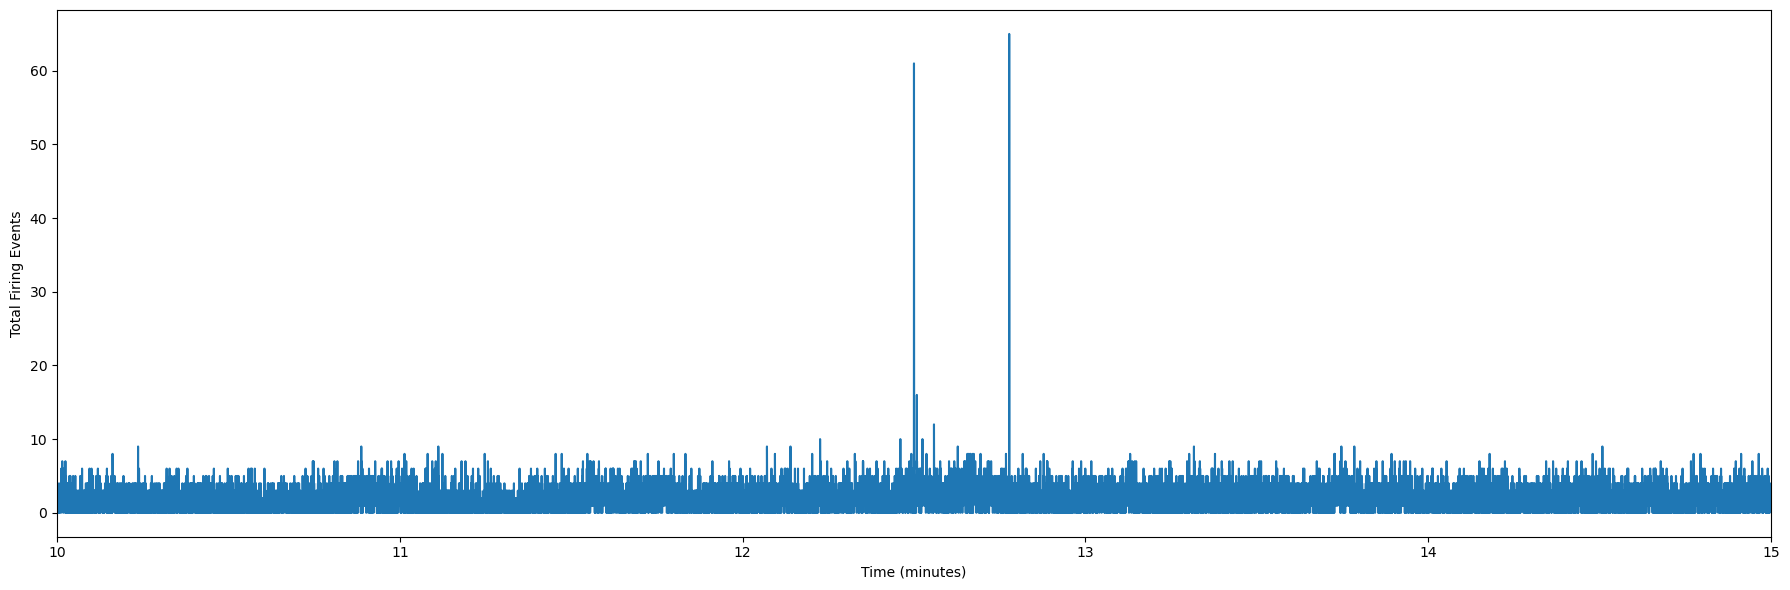

In [5]:
fps = 60
C_sum = np.sum(C_fires, axis=0)

# Convert the frame range to minutes by dividing by (fps * 60)
time_minutes = np.arange(n1 * fps * 60, n2 * fps * 60) / (fps * 60)

plt.figure(figsize=(18, 6))
plt.plot(time_minutes, C_sum)

minute_ticks = np.arange(n1, n2 + 1, 1)
plt.xticks(minute_ticks)
plt.xlim(n1, n2)

plt.xlabel('Time (minutes)')
plt.ylabel('Total Firing Events')
plt.tight_layout()

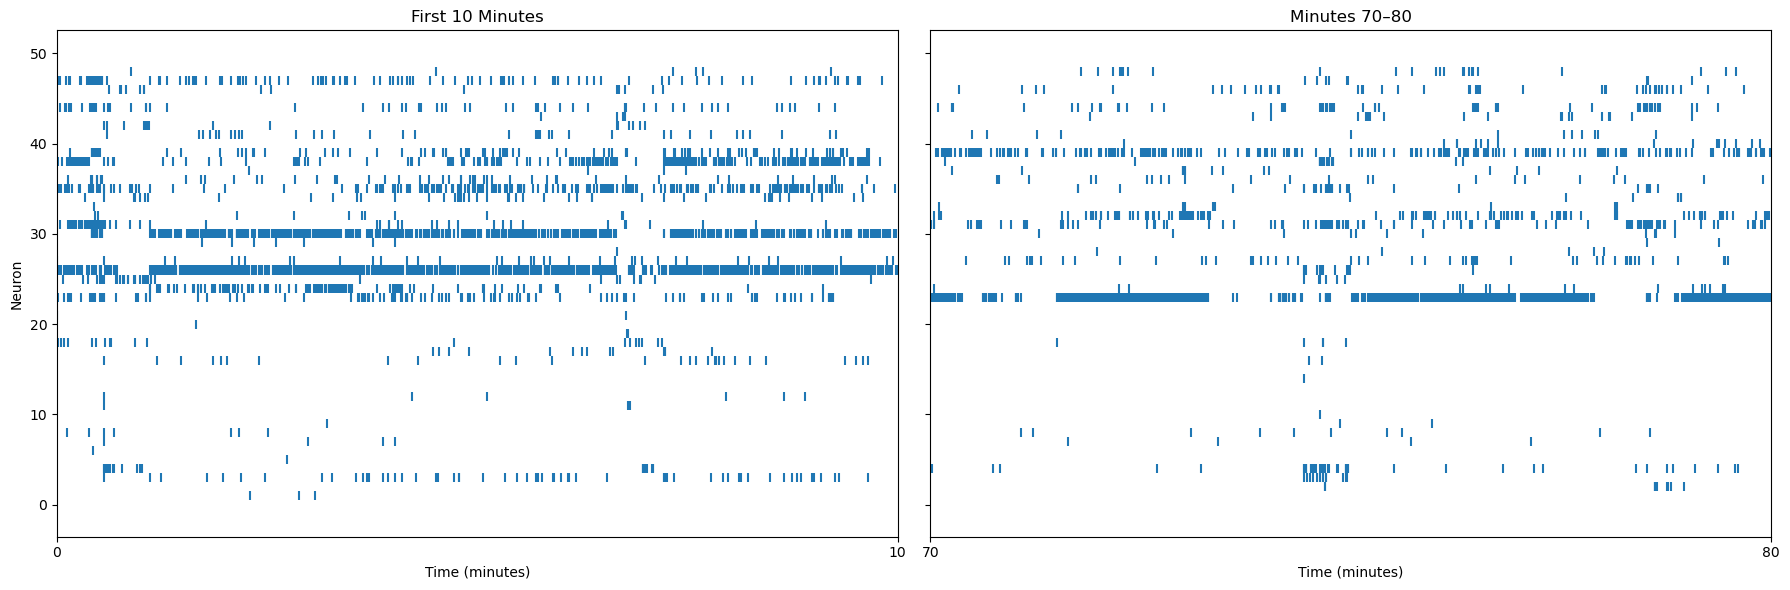

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

# --- First 10 minutes ---
ax1.eventplot(event_times[:50])
ax1.set_xlim(0, 10)
ax1.set_xticks(np.arange(0, 11, n))
ax1.set_xlabel('Time (minutes)')
ax1.set_ylabel('Neuron')
ax1.set_title('First 10 Minutes')

# --- 70-80 minutes ---
ax2.eventplot(event_times[:50])
ax2.set_xlim(70, 80)
ax2.set_xticks(np.arange(70, 81, n))
ax2.set_xlabel('Time (minutes)')
ax2.set_title('Minutes 70–80')

plt.tight_layout()
plt.savefig('/Users/josieallred/Research/experiment_analysis/data_analysis/before_after_ketamine2.png', dpi=150)

In [16]:
path = '/Users/josieallred/Research/experiment_analysis/data/downloaded_data/K99/miniscope_data/ketamine/R230706A/2023_08_31/15_17_10/Miniscope/1.avi'

In [17]:
# look into avi files
import cv2

cap = cv2.VideoCapture(path)

fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

duration = frame_count / fps

print("FPS:", fps)
print("Frames:", frame_count)
print("Resolution:", width, "x", height)
print("Duration:", duration, "seconds")

cap.release()


FPS: 60.0
Frames: 1000
Resolution: 608 x 608
Duration: 16.666666666666668 seconds
